In [4]:
import kagglehub
import os

os.environ["KAGGLE_CACHE_HOME"] = "./data"

path = kagglehub.dataset_download("aalborguniversity/brackish-dataset")
print("Path to dataset files:", path)

Dataset saved to: ./data/brackish-dataset


In [ ]:
# YOLO dataset prepare
from src.prepare_dataset import main

main()

Building video index...
Found 89 videos

=== train ===
  done: 11739 frames, 0 skipped

=== val ===
  done: 1467 frames, 0 skipped

=== test ===
  done: 1468 frames, 0 skipped

Done. Update data/dataset.yaml classes if needed:
  0: fish  1: small_fish  2: crab  3: shrimp  4: jellyfish  5: starfish


In [6]:
import numpy as np
import pandas as pd
import cv2
import os

df_valid  = pd.read_csv("data/brackish-dataset/annotations/annotations_AAU/valid.csv", sep=";")
df_train = pd.read_csv("data/brackish-dataset/annotations/annotations_AAU/train.csv", sep=";")
df_test = pd.read_csv("data/brackish-dataset/annotations/annotations_AAU/test.csv", sep=";")


In [8]:
df_valid.head()

,Filename,Object ID,Annotation tag,Upper left corner X,Upper left corner Y,Lower right corner X,Lower right corner Y,split
0,2019-02-21_06-52-16to2019-02-21_06-52-34_1-003...,3,starfish,431,459,475,505,valid
1,2019-03-06_22-11-06to2019-03-06_22-11-17_1-015...,33,crab,640,365,680,385,valid
2,2019-03-06_22-11-06to2019-03-06_22-11-17_1-015...,34,crab,735,325,758,350,valid
3,2019-03-06_22-11-06to2019-03-06_22-11-17_1-015...,35,crab,733,487,762,516,valid
4,2019-03-06_22-11-06to2019-03-06_22-11-17_1-015...,141,crab,798,502,830,533,valid


In [6]:
import torch
import gc

gc.collect()
torch.cuda.empty_cache()
torch.cuda.ipc_collect()

In [2]:
from ultralytics import YOLO

CONFIGS = {
    "weak": dict(
        fliplr=0.5,
        hsv_h=0.014,    # HueSaturationValue hue_shift_limit=5  (5/360)
        hsv_s=0.1,      # HueSaturationValue sat_shift_limit=10
        hsv_v=0.1,      # RandomBrightnessContrast brightness_limit=0.1
        degrees=0,
        translate=0.0,
        scale=0.0,
    ),
    "medium": dict(
        fliplr=0.5,
        hsv_h=0.05,     # ColorJitter hue=0.05
        hsv_s=0.2,      # ColorJitter saturation=0.2
        hsv_v=0.2,      # ColorJitter brightness=0.2
        degrees=10,     # ShiftScaleRotate rotate_limit=10
        translate=0.05, # ShiftScaleRotate shift_limit=0.05
        scale=0.15,     # ShiftScaleRotate scale_limit=0.15
    ),
    "strong": dict(
        fliplr=0.5,
        hsv_h=0.1,      # ColorJitter hue=0.1
        hsv_s=0.3,      # ColorJitter saturation=0.3
        hsv_v=0.3,      # ColorJitter brightness=0.3
        degrees=15,     # ShiftScaleRotate rotate_limit=15
        translate=0.1,  # ShiftScaleRotate shift_limit=0.1
        scale=0.3,      # ShiftScaleRotate scale_limit=0.3
    ),
}


In [ ]:

import matplotlib.pyplot as plt
from matplotlib import gridspec

TAG_COL = "Annotation tag"
COLORS  = {"train": "#5B8CF5", "valid": "#F5A742", "test": "#E05C5C"}

for df, name in [(df_train, "train"), (df_valid, "valid"), (df_test, "test")]:
    df["split"] = name

df_all = pd.concat([df_train, df_valid, df_test], ignore_index=True)

# ── Сводная таблица ───────────────────────────────────────────────────────────
counts = (
    df_all.groupby([TAG_COL, "split"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=["train", "valid", "test"], fill_value=0)
)
counts["total"] = counts.sum(axis=1)
counts = counts.sort_values("total", ascending=False)

print("── Количество объектов по классам ──────────────────")
print(counts.to_string())
print(f"\nИтого объектов: {counts['total'].sum()}")
print(f"Классов:        {len(counts)}")

# ── Фигура ────────────────────────────────────────────────────────────────────
classes = counts.index.tolist()
n = len(classes)
y = np.arange(n)

fig = plt.figure(figsize=(18, max(6, n * 0.55 + 3)))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# 1. Stacked bar — абсолютные числа
ax1 = fig.add_subplot(gs[0, :2])
left = np.zeros(n)
for split in ["train", "valid", "test"]:
    vals = counts[split].values
    bars = ax1.barh(y, vals, left=left, color=COLORS[split], label=split, alpha=0.9)
    left += vals

for i, (cls, row) in enumerate(counts.iterrows()):
    ax1.text(row["total"] + counts["total"].max() * 0.01, i,
             str(row["total"]), va="center", fontsize=9)

ax1.set_yticks(y)
ax1.set_yticklabels(classes)
ax1.set_xlabel("Количество объектов")
ax1.set_title("Объектов по классам и сплитам")
ax1.legend(loc="lower right")
ax1.grid(True, alpha=0.2, axis="x")
ax1.invert_yaxis()

# 2. Доля каждого класса от общего (pie / bar)
ax2 = fig.add_subplot(gs[0, 2])
pcts = counts["total"] / counts["total"].sum() * 100
cmap = plt.cm.get_cmap("tab10", n)
bars2 = ax2.barh(y, pcts.values, color=[cmap(i) for i in range(n)], alpha=0.85)
for i, v in enumerate(pcts.values):
    ax2.text(v + 0.3, i, f"{v:.1f}%", va="center", fontsize=8)
ax2.set_yticks(y)
ax2.set_yticklabels(classes)
ax2.set_xlabel("% от всего датасета")
ax2.set_title("Доля класса в датасете")
ax2.grid(True, alpha=0.2, axis="x")
ax2.invert_yaxis()

# 3. Train/valid/test split ratio по классу
ax3 = fig.add_subplot(gs[1, :2])
left = np.zeros(n)
for split in ["train", "valid", "test"]:
    ratio = counts[split].values / counts["total"].values * 100
    ax3.barh(y, ratio, left=left, color=COLORS[split], label=split, alpha=0.9)
    for i, (r, l) in enumerate(zip(ratio, left)):
        if r > 4:
            ax3.text(l + r / 2, i, f"{r:.0f}%",
                     ha="center", va="center", fontsize=8, color="white")
    left += ratio

ax3.set_yticks(y)
ax3.set_yticklabels(classes)
ax3.set_xlabel("%")
ax3.set_title("Распределение сплитов внутри класса")
ax3.set_xlim(0, 100)
ax3.legend(loc="lower right")
ax3.invert_yaxis()

# 4. Дисбаланс — отношение max/min класса по train
ax4 = fig.add_subplot(gs[1, 2])
train_counts = counts["train"].sort_values(ascending=False)
ratio_to_max = train_counts / train_counts.max()
bar_colors   = ["#E05C5C" if r < 0.1 else "#F5A742" if r < 0.3 else "#5B8CF5"
                for r in ratio_to_max]
ax4.barh(range(len(train_counts)), ratio_to_max.values,
         color=bar_colors, alpha=0.85)
ax4.set_yticks(range(len(train_counts)))
ax4.set_yticklabels(train_counts.index)
ax4.axvline(0.1, color="#E05C5C", linestyle="--", linewidth=1, alpha=0.7, label="< 10% от макс.")
ax4.axvline(0.3, color="#F5A742", linestyle="--", linewidth=1, alpha=0.7, label="< 30% от макс.")
ax4.set_xlabel("Доля от самого частого класса (train)")
ax4.set_title("Дисбаланс классов (train)")
ax4.legend(fontsize=8)
ax4.grid(True, alpha=0.2, axis="x")
ax4.invert_yaxis()

plt.suptitle("EDA — распределение классов", fontsize=14)
plt.savefig("eda_classes.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Объекты на изображение ────────────────────────────────────────────────────
print("\n── Объектов на изображение ─────────────────────────")
for df, name in [(df_train, "train"), (df_valid, "valid"), (df_test, "test")]:
    obj_per_img = df.groupby("Filename").size()
    print(f"{name:6}  mean={obj_per_img.mean():.2f}  "
          f"median={obj_per_img.median():.0f}  "
          f"max={obj_per_img.max()}  "
          f"imgs={len(obj_per_img)}")

── Количество объектов по классам ──────────────────
split           train  valid  test  total
Annotation tag                           
crab             9880   1189  1279  12348
small_fish       8655   1148   965  10768
starfish         6339    791   782   7912
fish             2709    322   321   3352
jellyfish         520     55    62    637
shrimp            415     76    57    548

Итого объектов: 35565
Классов:        6


NameError: name 'gridspec' is not defined

<Figure size 1800x630 with 0 Axes>

In [ ]:

def train_experiment(name, aug_params):
    model = YOLO("yolov8s.pt")
    model.train(
        data="data/dataset.yaml",
        epochs=30,
        imgsz=640,
        batch=32,
        device=0,
        workers=0,
        patience=10,
        project="runs/augmentation_study",
        name=name,
        **aug_params,
    )

for exp_name, cfg in CONFIGS.items():
    train_experiment(exp_name, cfg)


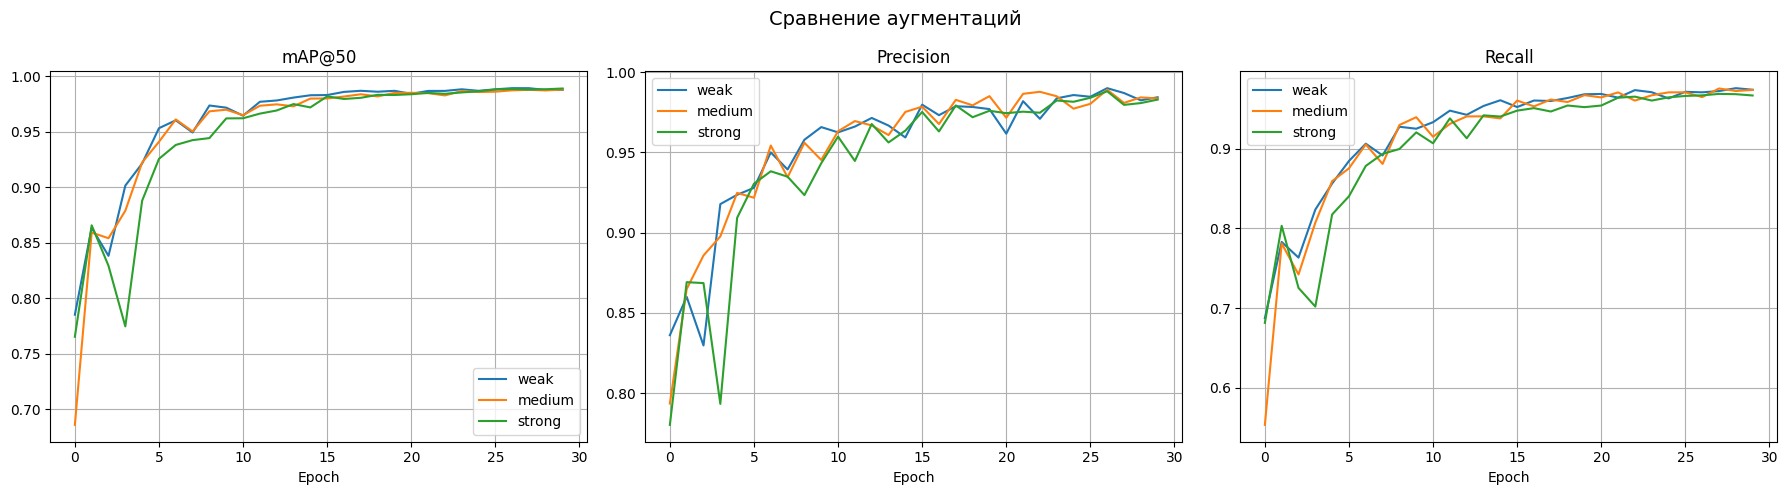

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

EXPERIMENTS = ["weak", "medium", "strong"]
METRICS = {
    "mAP@50":    "metrics/mAP50(B)",
    "Precision": "metrics/precision(B)",
    "Recall":    "metrics/recall(B)",
}

results = {}
for name in EXPERIMENTS:
    path = Path(f"runs/detect/runs/augmentation_study/{name}/results.csv")
    if path.exists():
        results[name] = pd.read_csv(path, skipinitialspace=True)
    else:
        print(f"[warn] не найдено: {path}")

fig, axes = plt.subplots(1, len(METRICS), figsize=(18, 5))

for ax, (title, col) in zip(axes, METRICS.items()):
    for name, df in results.items():
        if col in df.columns:
            ax.plot(df[col], label=name)
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.legend()
    ax.grid(True)

plt.suptitle("Сравнение аугментаций", fontsize=14)
plt.tight_layout()
plt.show()


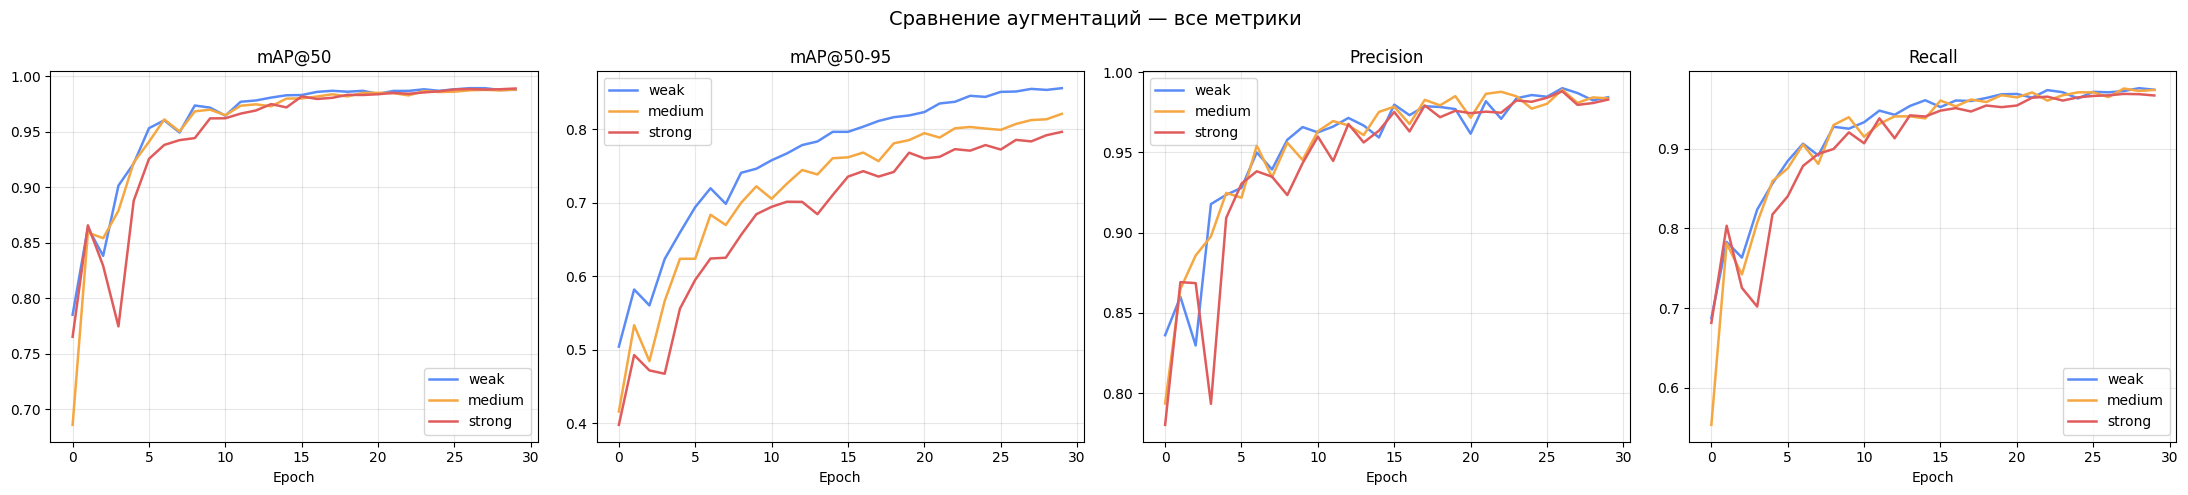

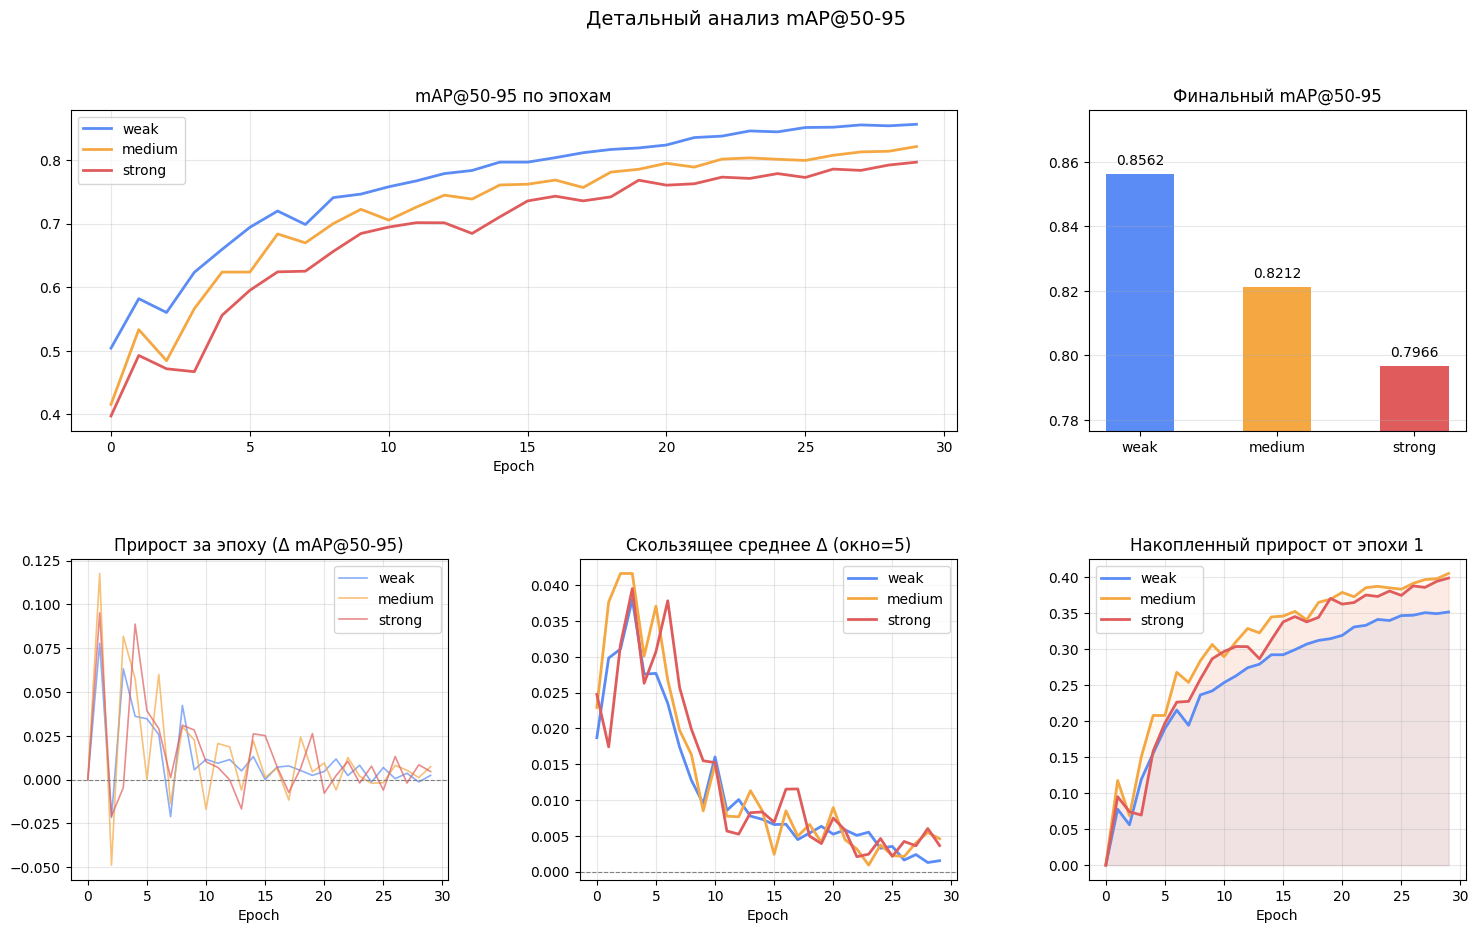


── mAP@50-95 summary ──────────────────────────────
            final     best  best_ep   Δtotal   Δlast5
weak       0.8562   0.8562       30  +0.3520  +0.0119
medium     0.8212   0.8212       30  +0.4055  +0.0200
strong     0.7966   0.7966       30  +0.3991  +0.0180


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from pathlib import Path

EXPERIMENTS = ["weak", "medium", "strong"]
COLORS = {"weak": "#5B8CF5", "medium": "#F5A742", "strong": "#E05C5C"}

results = {}
for name in EXPERIMENTS:
    path = Path(f"runs/detect/runs/augmentation_study/{name}/results.csv")
    if path.exists():
        results[name] = pd.read_csv(path, skipinitialspace=True)
    else:
        print(f"[warn] не найдено: {path}")

# ── Фигура 1: обзор всех метрик ──────────────────────────────────────────────
METRICS = {
    "mAP@50":      "metrics/mAP50(B)",
    "mAP@50-95":   "metrics/mAP50-95(B)",
    "Precision":   "metrics/precision(B)",
    "Recall":      "metrics/recall(B)",
}

fig1, axes = plt.subplots(1, len(METRICS), figsize=(22, 5))
for ax, (title, col) in zip(axes, METRICS.items()):
    for name, df in results.items():
        if col in df.columns:
            ax.plot(df[col], label=name, color=COLORS[name], linewidth=1.8)
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle("Сравнение аугментаций — все метрики", fontsize=14)
plt.tight_layout()
plt.savefig("aug_overview.png", dpi=150)
plt.show()

# ── Фигура 2: детальный анализ mAP@50-95 ─────────────────────────────────────
col = "metrics/mAP50-95(B)"
series = {name: df[col].values for name, df in results.items() if col in df.columns}

def smooth(arr, window=5):
    return pd.Series(arr).rolling(window, min_periods=1, center=True).mean().values

fig2 = plt.figure(figsize=(18, 10))
gs = gridspec.GridSpec(2, 3, figure=fig2, hspace=0.4, wspace=0.35)

# 1. Кривые mAP@50-95
ax1 = fig2.add_subplot(gs[0, :2])
for name, vals in series.items():
    ax1.plot(vals, label=name, color=COLORS[name], linewidth=2)
ax1.set_title("mAP@50-95 по эпохам")
ax1.set_xlabel("Epoch")
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Итоговые значения (bar)
ax2 = fig2.add_subplot(gs[0, 2])
names = list(series.keys())
final_vals = [series[n][-1] for n in names]
bars = ax2.bar(names, final_vals, color=[COLORS[n] for n in names], width=0.5)
for bar, val in zip(bars, final_vals):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002,
             f"{val:.4f}", ha="center", va="bottom", fontsize=10)
ax2.set_ylim(min(final_vals) - 0.02, max(final_vals) + 0.02)
ax2.set_title("Финальный mAP@50-95")
ax2.grid(True, alpha=0.3, axis="y")

# 3. Прирост за эпоху (Δ)
ax3 = fig2.add_subplot(gs[1, 0])
for name, vals in series.items():
    delta = np.diff(vals, prepend=vals[0])
    ax3.plot(delta, label=name, color=COLORS[name], linewidth=1.2, alpha=0.7)
ax3.axhline(0, color="gray", linewidth=0.8, linestyle="--")
ax3.set_title("Прирост за эпоху (Δ mAP@50-95)")
ax3.set_xlabel("Epoch")
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. Скользящее среднее Δ
ax4 = fig2.add_subplot(gs[1, 1])
for name, vals in series.items():
    delta = np.diff(vals, prepend=vals[0])
    ax4.plot(smooth(delta, window=5), label=name, color=COLORS[name], linewidth=2)
ax4.axhline(0, color="gray", linewidth=0.8, linestyle="--")
ax4.set_title("Скользящее среднее Δ (окно=5)")
ax4.set_xlabel("Epoch")
ax4.legend()
ax4.grid(True, alpha=0.3)

# 5. Накопленный прирост
ax5 = fig2.add_subplot(gs[1, 2])
for name, vals in series.items():
    cumul = vals - vals[0]
    ax5.plot(cumul, label=name, color=COLORS[name], linewidth=2)
    ax5.fill_between(range(len(cumul)), cumul, alpha=0.08, color=COLORS[name])
ax5.set_title("Накопленный прирост от эпохи 1")
ax5.set_xlabel("Epoch")
ax5.legend()
ax5.grid(True, alpha=0.3)

plt.suptitle("Детальный анализ mAP@50-95", fontsize=14)
plt.savefig("aug_map5095_detail.png", dpi=150)
plt.show()

# ── Сводная таблица ───────────────────────────────────────────────────────────
print("\n── mAP@50-95 summary ──────────────────────────────")
print(f"{'':8} {'final':>8} {'best':>8} {'best_ep':>8} {'Δtotal':>8} {'Δlast5':>8}")
for name, vals in series.items():
    final   = vals[-1]
    best    = vals.max()
    best_ep = vals.argmax() + 1
    d_total = vals[-1] - vals[0]
    d_last5 = vals[-1] - vals[-6]
    print(f"{name:8} {final:8.4f} {best:8.4f} {best_ep:8d} {d_total:+8.4f} {d_last5:+8.4f}")

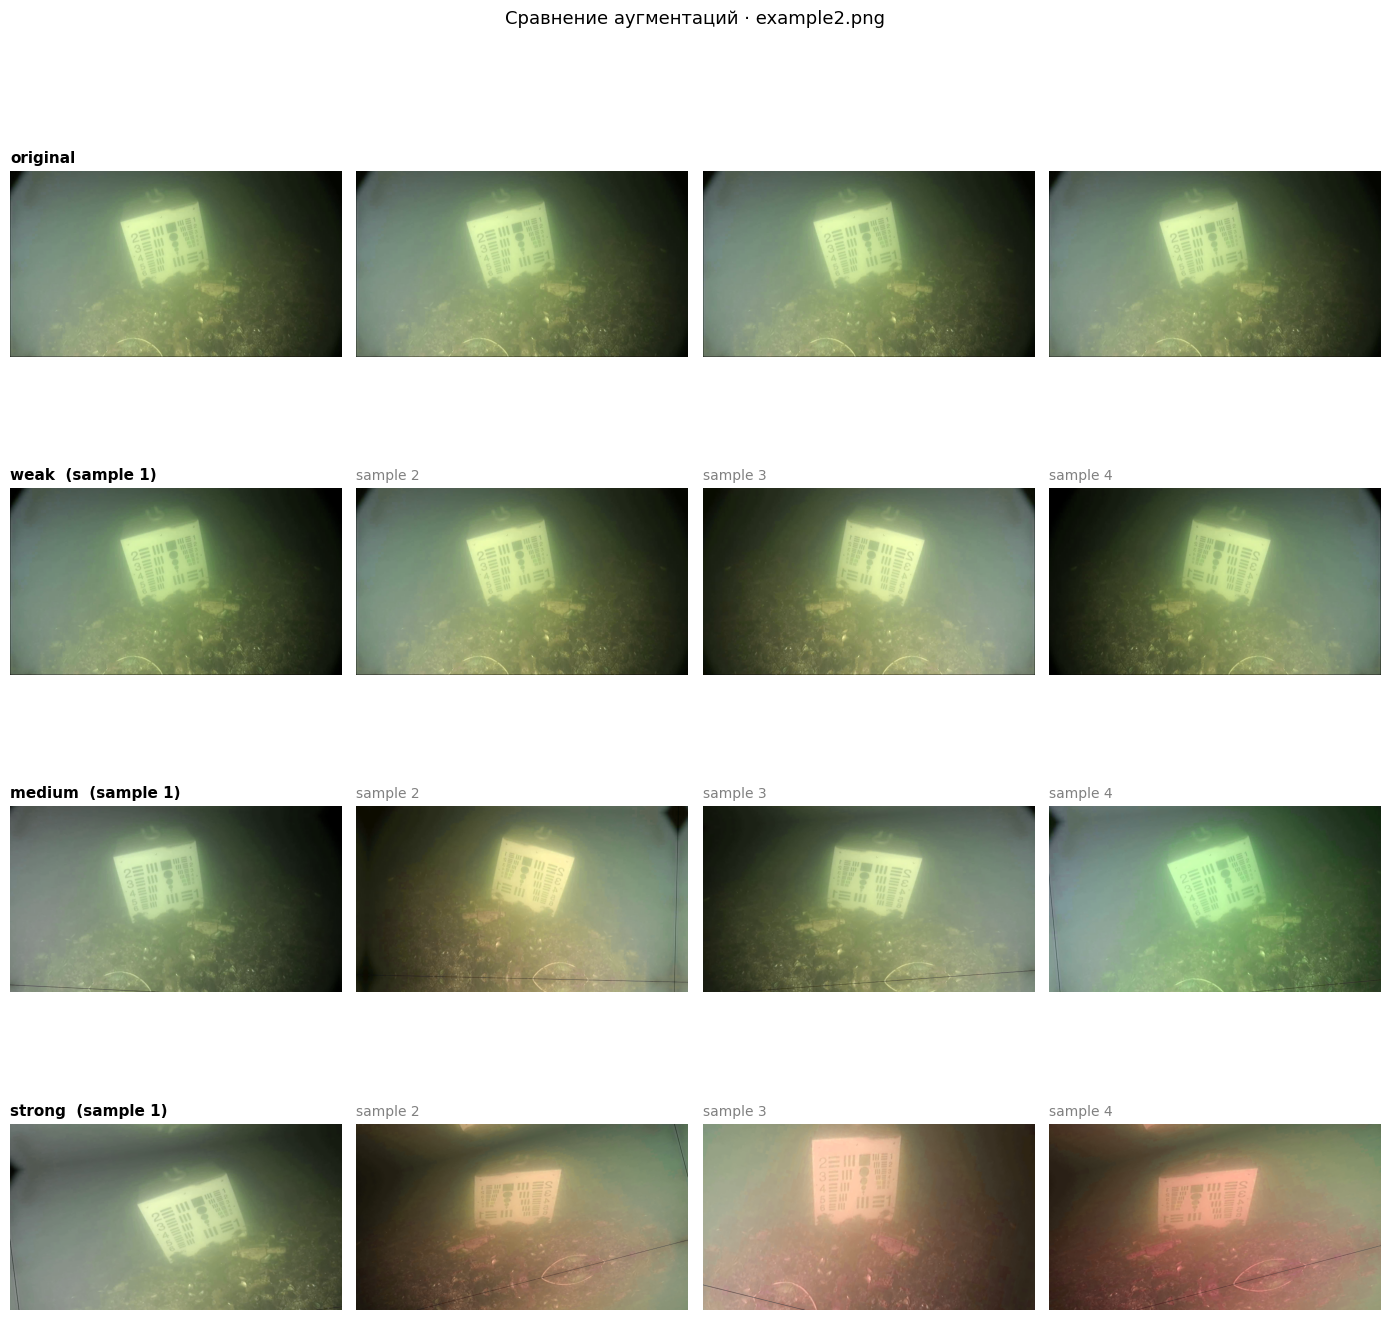

Сохранено: aug_comparison.png


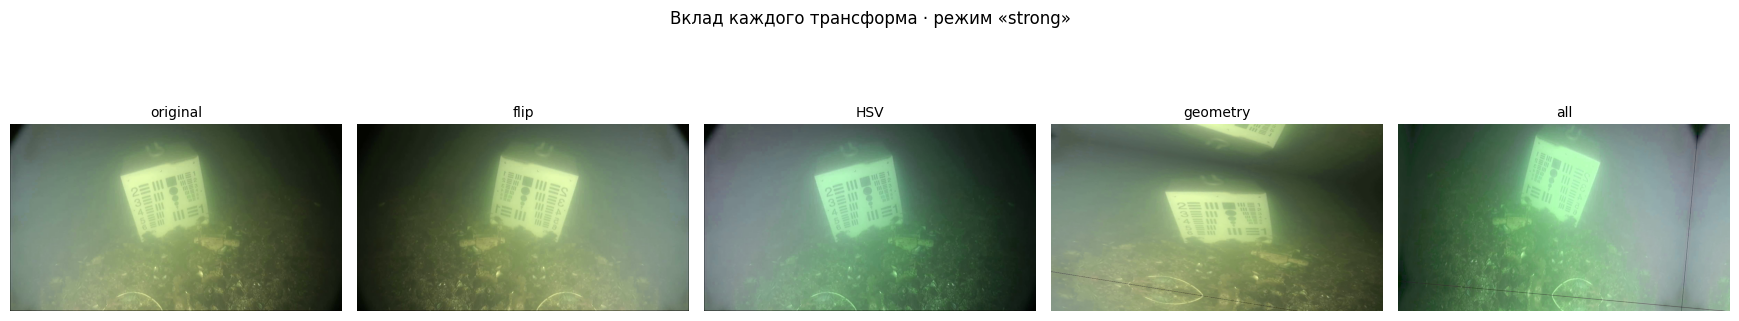

Сохранено: aug_individual_strong.png


In [4]:
import cv2
import numpy as np
import albumentations as A
import matplotlib.pyplot as plt
from pathlib import Path

def build_pipeline(cfg: dict) -> A.Compose:
    """Собирает pipeline Albumentations из параметров YOLO-конфига."""
    transforms = []

    # Горизонтальный флип
    if cfg.get("fliplr", 0) > 0:
        transforms.append(A.HorizontalFlip(p=cfg["fliplr"]))

    # HSV — переводим доли YOLO в абсолютные лимиты Albumentations
    hue_limit   = int(cfg.get("hsv_h", 0) * 360)  # YOLO: 0-1 доля от 360°
    sat_limit   = int(cfg.get("hsv_s", 0) * 100)  # YOLO: 0-1 доля от 100
    val_limit   = int(cfg.get("hsv_v", 0) * 100)
    if any([hue_limit, sat_limit, val_limit]):
        transforms.append(A.HueSaturationValue(
            hue_shift_limit=hue_limit,
            sat_shift_limit=sat_limit,
            val_shift_limit=val_limit,
            p=1.0,
        ))

    # Геометрия: поворот + сдвиг + масштаб
    degrees   = cfg.get("degrees", 0)
    translate = cfg.get("translate", 0.0)
    scale     = cfg.get("scale", 0.0)
    if any([degrees, translate, scale]):
        transforms.append(A.ShiftScaleRotate(
            shift_limit=translate,
            scale_limit=scale,
            rotate_limit=degrees,
            border_mode=cv2.BORDER_REFLECT_101,
            p=1.0,
        ))

    return A.Compose(transforms)


def apply_n_times(pipeline: A.Compose, image: np.ndarray, n: int) -> list[np.ndarray]:
    return [pipeline(image=image)["image"] for _ in range(n)]


def show_comparison(image_path: str, configs: dict, n_samples: int = 4):
    img_bgr = cv2.imread(image_path)
    assert img_bgr is not None, f"Не удалось загрузить изображение: {image_path}"
    img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    n_rows = len(configs) + 1          # +1 для оригинала
    n_cols = n_samples

    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(n_cols * 3.5, n_rows * 3.5),
    )
    # Гарантируем 2D-массив даже при n_cols=1
    axes = np.atleast_2d(axes)

    # Первая строка — оригинал (повторяем в каждой колонке)
    for col in range(n_cols):
        axes[0, col].imshow(img)
        axes[0, col].axis("off")
        if col == 0:
            axes[0, col].set_title("original", fontsize=11, fontweight="bold", loc="left")

    # Остальные строки — аугментированные варианты
    for row_idx, (name, cfg) in enumerate(configs.items(), start=1):
        pipeline = build_pipeline(cfg)
        samples  = apply_n_times(pipeline, img, n_samples)

        for col, sample in enumerate(samples):
            axes[row_idx, col].imshow(sample)
            axes[row_idx, col].axis("off")
            if col == 0:
                axes[row_idx, col].set_title(
                    f"{name}  (sample {col + 1})",
                    fontsize=11, fontweight="bold", loc="left",
                )
            else:
                axes[row_idx, col].set_title(
                    f"sample {col + 1}",
                    fontsize=10, loc="left", color="gray",
                )

    plt.suptitle(
        f"Сравнение аугментаций · {Path(image_path).name}",
        fontsize=13, y=1.01,
    )
    plt.tight_layout()
    plt.savefig("aug_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Сохранено: aug_comparison.png")


# ── Дополнительно: посмотреть каждый трансформ по отдельности ────────────────

def show_individual_transforms(image_path: str, config_name: str = "strong"):
    img_bgr = cv2.imread(image_path)
    img     = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    cfg     = CONFIGS[config_name]

    individual = {
        "original": A.Compose([]),
        "flip":     A.Compose([A.HorizontalFlip(p=1.0)]),
        "HSV":      A.Compose([A.HueSaturationValue(
                        hue_shift_limit=int(cfg["hsv_h"] * 360),
                        sat_shift_limit=int(cfg["hsv_s"] * 100),
                        val_shift_limit=int(cfg["hsv_v"] * 100),
                        p=1.0)]),
        "geometry": A.Compose([A.ShiftScaleRotate(
                        shift_limit=cfg["translate"],
                        scale_limit=cfg["scale"],
                        rotate_limit=cfg["degrees"],
                        border_mode=cv2.BORDER_REFLECT_101,
                        p=1.0)]),
        "all":      build_pipeline(cfg),
    }

    fig, axes = plt.subplots(1, len(individual), figsize=(len(individual) * 3.5, 4))
    for ax, (label, pipeline) in zip(axes, individual.items()):
        result = pipeline(image=img)["image"]
        ax.imshow(result)
        ax.set_title(label, fontsize=10)
        ax.axis("off")

    plt.suptitle(f"Вклад каждого трансформа · режим «{config_name}»", fontsize=12)
    plt.tight_layout()
    plt.savefig(f"aug_individual_{config_name}.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Сохранено: aug_individual_{config_name}.png")


# ── Запуск ────────────────────────────────────────────────────────────────────
IMAGE_PATH = "example2.png"
N_SAMPLES = 4 

show_comparison(IMAGE_PATH, CONFIGS, n_samples=N_SAMPLES)
show_individual_transforms(IMAGE_PATH, config_name="strong")

In [40]:
import cv2
from pathlib import Path

def extract_frame(video_path, frame_num, output_path):
    cap = cv2.VideoCapture(video_path)

    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_num)
    ret, frame = cap.read()

    if not ret:
        raise RuntimeError("Error while img reading")

    frame = cv2.resize(frame, (960, 540))
    cv2.imwrite(output_path, frame)
    cap.release()

video = "data/dataset/videos/crab/2019-03-21_07-40-40to2019-03-21_07-40-50_1.avi"

extract_frame(
    video_path=video,
    frame_num=70,
    output_path="example.png"
)

/var/folders/2p/1g0tbznd1zg9118y89qrclsc0000gn/T/ipykernel_28599/2446248381.py:14: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  transforms.append(getattr(A, name)(**params))


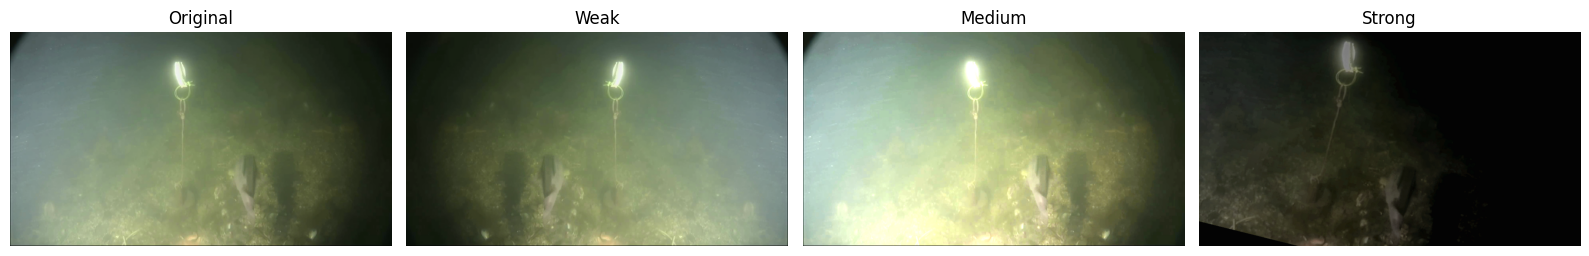

In [33]:
import cv2
import albumentations as A
import matplotlib.pyplot as plt
import yaml

def load_pipeline(config_path):
    with open(config_path, "r") as f:
        cfg = yaml.safe_load(f)

    transforms = []
    for t in cfg["train"]:
        name = list(t.keys())[0]
        params = t[name] or {}
        transforms.append(getattr(A, name)(**params))

    return A.Compose(transforms)

def show_augmentations(image_path):
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    pipelines = {
        "Original": None,
        "Weak": load_pipeline("config/albumentations_weak.yaml"),
        "Medium": load_pipeline("config/albumentations_medium.yaml"),
        "Strong": load_pipeline("config/albumentations_strong.yaml"),
    }

    plt.figure(figsize=(16, 4))

    for i, (name, aug) in enumerate(pipelines.items()):
        plt.subplot(1, 4, i + 1)

        if aug is None:
            aug_image = image
        else:
            aug_image = aug(image=image)["image"]

        plt.imshow(aug_image)
        plt.title(name)
        plt.axis("off")

    plt.tight_layout()
    plt.show()
show_augmentations("example.png")

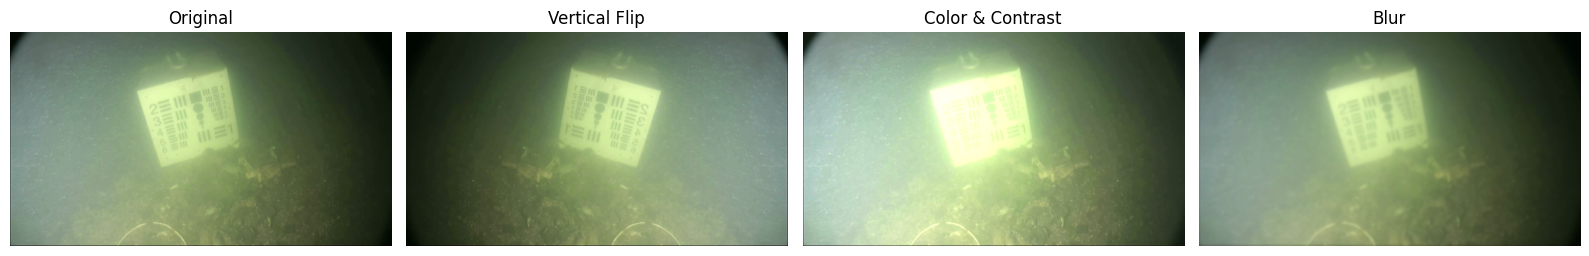

In [ ]:
import cv2
import albumentations as A
import matplotlib.pyplot as plt

def show_simple_augmentations(image_path):
    # Загружаем изображение и конвертируем в RGB
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Определяем простые пайплайны для каждой трансформации
    pipelines = {
        "Original": None,
        "Vertical Flip": A.Compose([A.HorizontalFlip(p=1.0)]),
        "Color & Contrast": A.Compose([A.RandomBrightnessContrast(brightness_limit=0.35, contrast_limit=0.6, p=1.0)]),
        "Blur": A.Compose([A.GaussianBlur(blur_limit=40, p=1.0)])
    }

    # Создаём фигуру для отображения
    plt.figure(figsize=(16, 4))

    for i, (name, aug) in enumerate(pipelines.items()):
        plt.subplot(1, 4, i + 1)

        if aug is None:
            aug_image = image
        else:
            aug_image = aug(image=image)["image"]

        plt.imshow(aug_image)
        plt.title(name)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

# Использование функции
show_simple_augmentations("example2.png")